## Download Data

In [1]:
import os, json

with open('creds.json') as f:
    creds = json.load(f)

os.environ['KAGGLE_USERNAME'] = creds['username']
os.environ['KAGGLE_KEY'] = creds['key']

!pip install -q kaggle
!kaggle datasets download -d Cornell-University/arxiv
!unzip -q arxiv.zip


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
100%|██████████████████████████████████████| 1.58G/1.58G [13:23<00:00, 2.12MB/s]



In [28]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
import time

np.random.seed(42)

In [5]:
DATA_PATH = 'arxiv-metadata-oai-snapshot.json'
MAX_PAPERS = 50_000

In [6]:
def load_arxiv(path, max_papers=None):
    records = []
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            if max_papers and i >= max_papers:
                break
            p = json.loads(line)
            records.append({
                'id': p['id'],
                'title': p['title'].strip().replace('\n', ' '),
                'abstract': p['abstract'].strip().replace('\n', ' '),
                'categories': p['categories'],
            })
    return pd.DataFrame(records)

t0 = time.time()
df = load_arxiv(DATA_PATH, MAX_PAPERS)
print(f'{len(df)} papers loaded in {time.time()-t0:.1f}s')

50000 papers loaded in 0.4s


In [7]:
df.head(3)

,id,title,abstract,categories
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,hep-ph
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",math.CO cs.CG
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,physics.gen-ph


In [8]:
df_small = df.sample(100, random_state=42).reset_index(drop=True)
df_med = df.sample(min(10000, len(df)), random_state=42).reset_index(drop=True)

# Algorithms

## Jaccard Similarity

In [9]:
def jaccard_sim(s, t):
    if not s and not t:
        return 1.0
    return len(s & t) / len(s | t)


def jaccard_bag_sim(b, c):
    cb, cc = Counter(b), Counter(c)
    all_keys = set(cb) | set(cc)
    inter = sum(min(cb[k], cc[k]) for k in all_keys)
    union = sum(cb[k] + cc[k] for k in all_keys)
    return inter / union if union else 1.0

In [10]:
word_sets = [set(a.lower().split()) for a in df_small['abstract']]

n = len(word_sets)
sim_matrix = np.zeros((n, n))

t0 = time.time()
for i in range(n):
    for j in range(i, n):
        s = jaccard_sim(word_sets[i], word_sets[j])
        sim_matrix[i,j] = s
        sim_matrix[j,i] = s

print(f'{n*(n-1)//2} pairs in {time.time()-t0:.2f}s')

4950 pairs in 0.03s


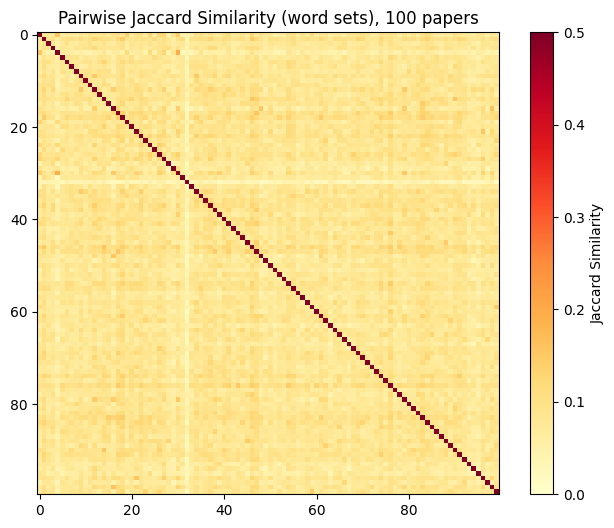

In [11]:
plt.figure(figsize=(8,6))
plt.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=0.5)
plt.colorbar(label='Jaccard Similarity')
plt.title('Pairwise Jaccard Similarity (word sets), 100 papers')
plt.show()

In [12]:
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((i, j, sim_matrix[i,j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print('Top 10 most similar pairs:')
for rank, (i, j, s) in enumerate(pairs[:10], 1):
    print(f'\n{rank}. sim={s:.4f}')
    print(f'   [{df_small.iloc[i]["categories"]}] {df_small.iloc[i]["title"][:80]}')
    print(f'   [{df_small.iloc[j]["categories"]}] {df_small.iloc[j]["title"][:80]}')

Top 10 most similar pairs:

1. sim=0.1951
   [math.RT math.AG math.RA] Symplectic reflection algebras
   [math.RT math.AG] Representations of quivers, their generalizations and invariants

2. sim=0.1594
   [math.CA] Functions of q-positive type
   [math.CA] Uniform estimates for cubic oscillatory integrals

3. sim=0.1573
   [gr-qc] Quantum cosmology with varying speed of light and Bohmian trajectories
   [math.FA] Integrable operators and squares of Hankel Matrices

4. sim=0.1569
   [hep-lat hep-ph] Recent lattice results on finite temerature and density QCD, part II
   [math.RT math.AG math.RA] Symplectic reflection algebras

5. sim=0.1569
   [gr-qc] Quantum cosmology with varying speed of light and Bohmian trajectories
   [quant-ph] The meeting problem in the quantum random walk

6. sim=0.1556
   [math.CA] Functions of q-positive type
   [math.AG math.GT] A note on local trigonal fibrations

7. sim=0.1550
   [math-ph math.MP] Poisson brackets in Hydrodynamics
   [math.CO] Quasi-perio

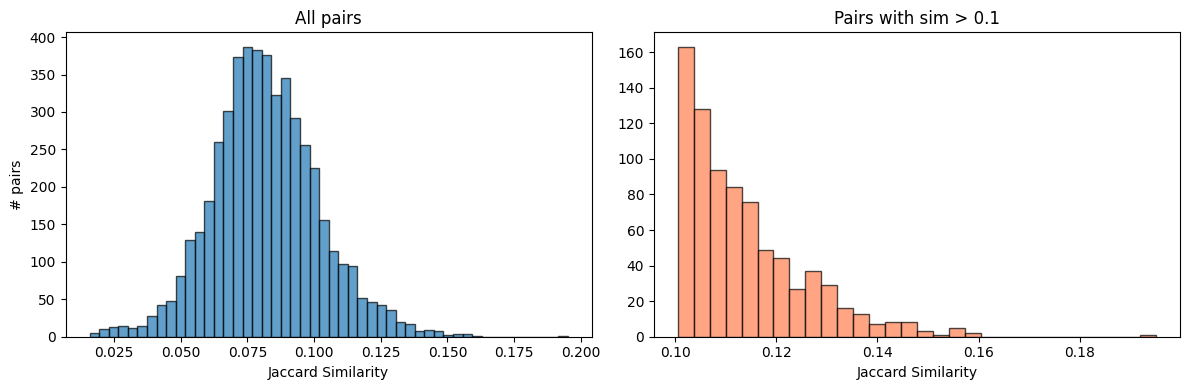

Pairs with sim > 0.1: 795
Pairs with sim > 0.2: 0
Pairs with sim > 0.3: 0


In [13]:
off_diag = sim_matrix[np.triu_indices(n, k=1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(off_diag, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Jaccard Similarity')
ax1.set_ylabel('# pairs')
ax1.set_title('All pairs')

ax2.hist(off_diag[off_diag > 0.1], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Jaccard Similarity')
ax2.set_title('Pairs with sim > 0.1')

plt.tight_layout()
plt.show()

for t in [0.1, 0.2, 0.3]:
    print(f'Pairs with sim > {t}: {(off_diag > t).sum()}')

In [14]:
for n_docs in [100, 1000, 10000, 50000, 1_000_000]:
    n_pairs = n_docs * (n_docs - 1) // 2
    sec = n_pairs * 1e-6
    if sec < 60: t = f'{sec:.1f}s'
    elif sec < 3600: t = f'{sec/60:.1f}min'
    elif sec < 86400: t = f'{sec/3600:.1f}hr'
    else: t = f'{sec/86400:.1f} days'
    print(f'n={n_docs:>10,}  pairs={n_pairs:>15,}  ~{t}')

n=       100  pairs=          4,950  ~0.0s
n=     1,000  pairs=        499,500  ~0.5s
n=    10,000  pairs=     49,995,000  ~50.0s
n=    50,000  pairs=  1,249,975,000  ~20.8min
n= 1,000,000  pairs=499,999,500,000  ~5.8 days


## Shingling

In [15]:
def k_shingles(doc, k):
    return {doc[i:i+k] for i in range(len(doc) - k + 1)}


def k_shingles_hashed(doc, k, n_buckets=2**32):
    return {hash(doc[i:i+k]) % n_buckets for i in range(len(doc) - k + 1)}


def word_shingles(doc, stop_words):
    words = doc.lower().split()
    shingles = set()
    for i, w in enumerate(words):
        if w in stop_words and i + 2 < len(words):
            shingles.add(f'{words[i]} {words[i+1]} {words[i+2]}')
    return shingles

In [17]:
for k in [3, 5, 7, 9]:
    sizes = [len(k_shingles(a.lower(), k)) for a in df_small['abstract']]
    print(f'k={k}: avg={np.mean(sizes):.0f} shingles per doc')

k=3: avg=438 shingles per doc
k=5: avg=607 shingles per doc
k=7: avg=672 shingles per doc
k=9: avg=703 shingles per doc


In [ ]:
k = 5
shingle_sets = [k_shingles(a.lower(), k) for a in df_small['abstract']]

print(f'{"pair":<10} {"word sets":<12} {"5-shingles":<12}')
for i, j in [(0,1), (0,2), (1,2), (0,50), (3,7)]:
    ws = jaccard_sim(word_sets[i], word_sets[j])
    ss = jaccard_sim(shingle_sets[i], shingle_sets[j])
    print(f'({i},{j})     {ws:<12.4f} {ss:<12.4f}')

pair       word sets    5-shingles  
(0,1)     0.0755       0.0354      
(0,2)     0.0753       0.0372      
(1,2)     0.0882       0.0297      
(0,50)     0.0800       0.0399      
(3,7)     0.0655       0.0318      


In [ ]:
shingles_9 = [k_shingles(a.lower(), 9) for a in df_small['abstract']]
hashed_sets = [k_shingles_hashed(a.lower(), 9) for a in df_small['abstract']]

for i, j in [(0,1), (0,2), (3,7)]:
    s_raw = jaccard_sim(shingles_9[i], shingles_9[j])
    s_hash = jaccard_sim(hashed_sets[i], hashed_sets[j])
    print(f'({i},{j})  raw: {s_raw:.4f}  hashed: {s_hash:.4f}')

(0,1)  raw: 0.0011  hashed: 0.0011
(0,2)  raw: 0.0010  hashed: 0.0010
(3,7)  raw: 0.0043  hashed: 0.0043


## Minhashing

In [22]:
def build_char_matrix(sets, universe):
    elem_to_row = {e: i for i, e in enumerate(universe)}
    M = np.zeros((len(universe), len(sets)), dtype=int)
    for c, s in enumerate(sets):
        for e in s:
            M[elem_to_row[e], c] = 1
    return M


def make_hash_funcs(n, num_rows):
    p = num_rows
    while True:
        if p > 1 and all(p % i != 0 for i in range(2, int(p**0.5)+1)):
            break
        p += 1
    funcs = []
    for _ in range(n):
        a = np.random.randint(1, p)
        b = np.random.randint(0, p)
        funcs.append((a, b, p))
    return funcs


def minhash_sig(char_matrix, hash_funcs):
    n_rows, n_cols = char_matrix.shape
    sig = np.full((len(hash_funcs), n_cols), np.inf)
    for r in range(n_rows):
        hvals = [(a * r + b) % p for a, b, p in hash_funcs]
        for c in range(n_cols):
            if char_matrix[r, c] == 1:
                for i, h in enumerate(hvals):
                    if h < sig[i, c]:
                        sig[i, c] = h
    return sig.astype(int)


def sig_similarity(sig, i, j):
    return np.mean(sig[:, i] == sig[:, j])

In [23]:
def minhash_from_sets(sets, hash_funcs):
    n_hashes = len(hash_funcs)
    sig = np.full((n_hashes, len(sets)), np.inf)

    elem_to_idx = {}
    idx = 0
    for s in sets:
        for e in s:
            if e not in elem_to_idx:
                elem_to_idx[e] = idx
                idx += 1

    for c, s in enumerate(sets):
        for e in s:
            r = elem_to_idx[e]
            for i, (a, b, p) in enumerate(hash_funcs):
                h = (a * r + b) % p
                if h < sig[i, c]:
                    sig[i, c] = h
    return sig.astype(int)

In [24]:
n_hashes = 100
hash_funcs = make_hash_funcs(n_hashes, 100000)

t0 = time.time()
sig_arxiv = minhash_from_sets(shingle_sets, hash_funcs)
print(f'{n_hashes} hashes, {len(shingle_sets)} docs in {time.time()-t0:.2f}s')
print(f'Signature matrix: {sig_arxiv.shape}')

100 hashes, 100 docs in 0.88s
Signature matrix: (100, 100)


In [ ]:
print(f'{"pair":<10} {"true":<10} {"minhash":<10}')
for i, j in [(0,1), (0,2), (1,2), (0,50), (3,7)]:
    true = jaccard_sim(shingle_sets[i], shingle_sets[j])
    est = sig_similarity(sig_arxiv, i, j)
    print(f'({i},{j})     {true:<10.4f} {est:<10.4f}')

pair       true       minhash   
(0,1)     0.0354     0.0500    
(0,2)     0.0372     0.0200    
(1,2)     0.0297     0.0400    
(0,50)     0.0399     0.0200    
(3,7)     0.0318     0.0400    


In [29]:
for nh in [10, 25, 50, 100, 200]:
    hf = make_hash_funcs(nh, 100000)
    sig_test = minhash_from_sets(shingle_sets[:20], hf)
    errors = []
    for i, j in combinations(range(20), 2):
        true = jaccard_sim(shingle_sets[i], shingle_sets[j])
        est = sig_similarity(sig_test, i, j)
        errors.append(abs(true - est))
    print(f'n_hashes={nh:<4}  MAE: {np.mean(errors):.4f}')

n_hashes=10    MAE: 0.0469
n_hashes=25    MAE: 0.0305
n_hashes=50    MAE: 0.0252
n_hashes=100   MAE: 0.0155
n_hashes=200   MAE: 0.0105
